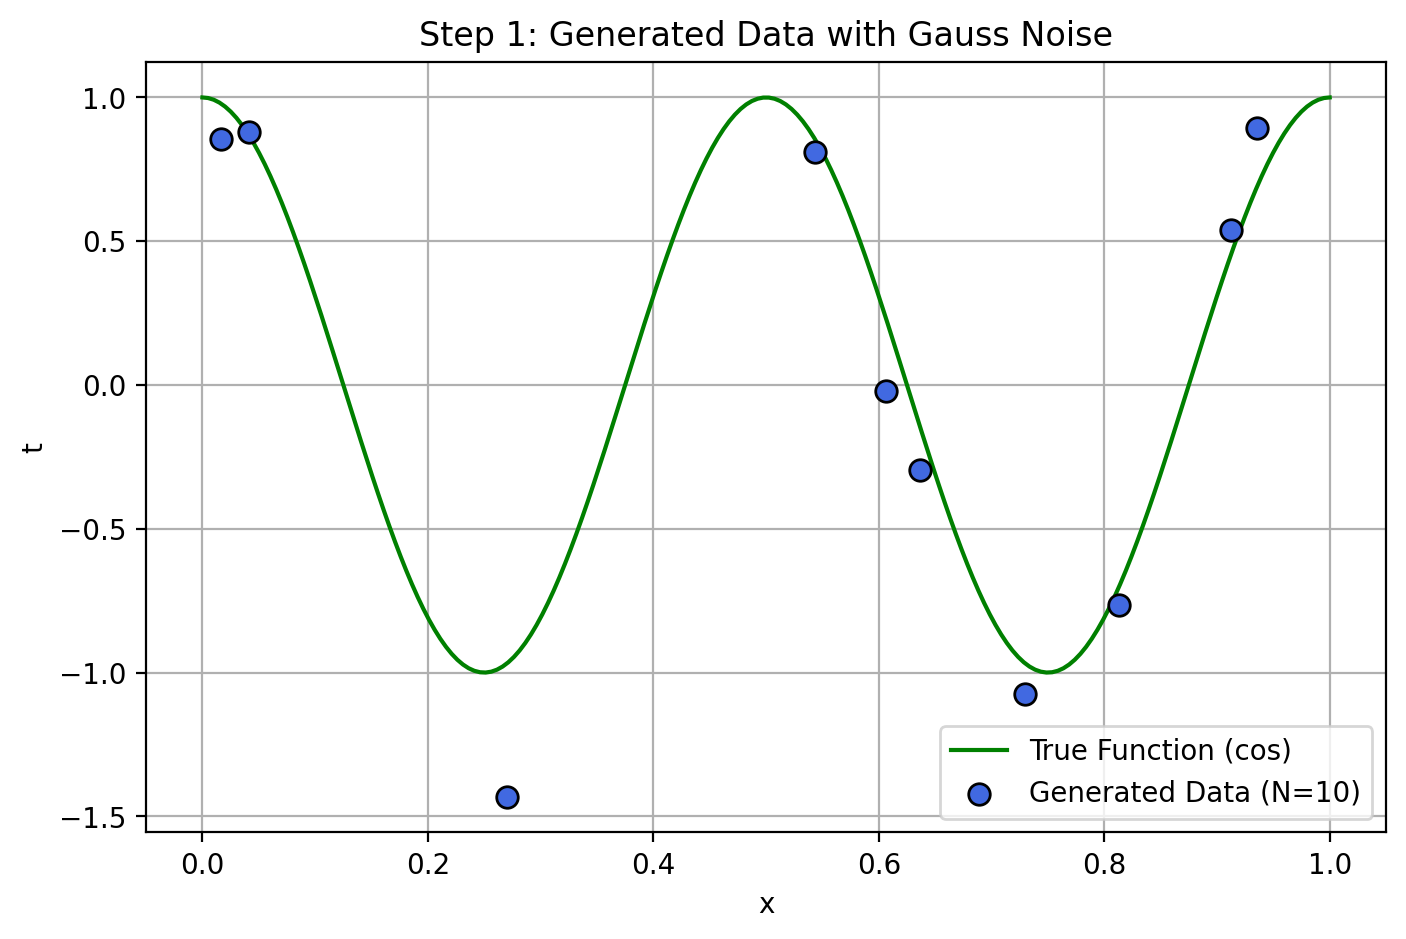

元のデータxの形状: (10,)
設計行列Phiの形状 (10データ × 4列): (10, 6)

最初の3データ分の設計行列の中身（1, x, x^2, x^3, x^4, x^5）:
[[1.00000000e+00 1.65276355e-02 2.73162736e-04 4.51473414e-06
  7.46178804e-08 1.23325713e-09]
 [1.00000000e+00 4.09735239e-02 1.67882966e-03 6.87875674e-05
  2.81846904e-06 1.15482609e-07]
 [1.00000000e+00 2.69786714e-01 7.27848709e-02 1.96363911e-02
  5.29763744e-03 1.42923219e-03]]
求まった最適な重み w (w0, w1, w2, w3, w4, w5):
[   1.73379  -35.54589  114.75833  -55.36972 -154.73447  134.06965]


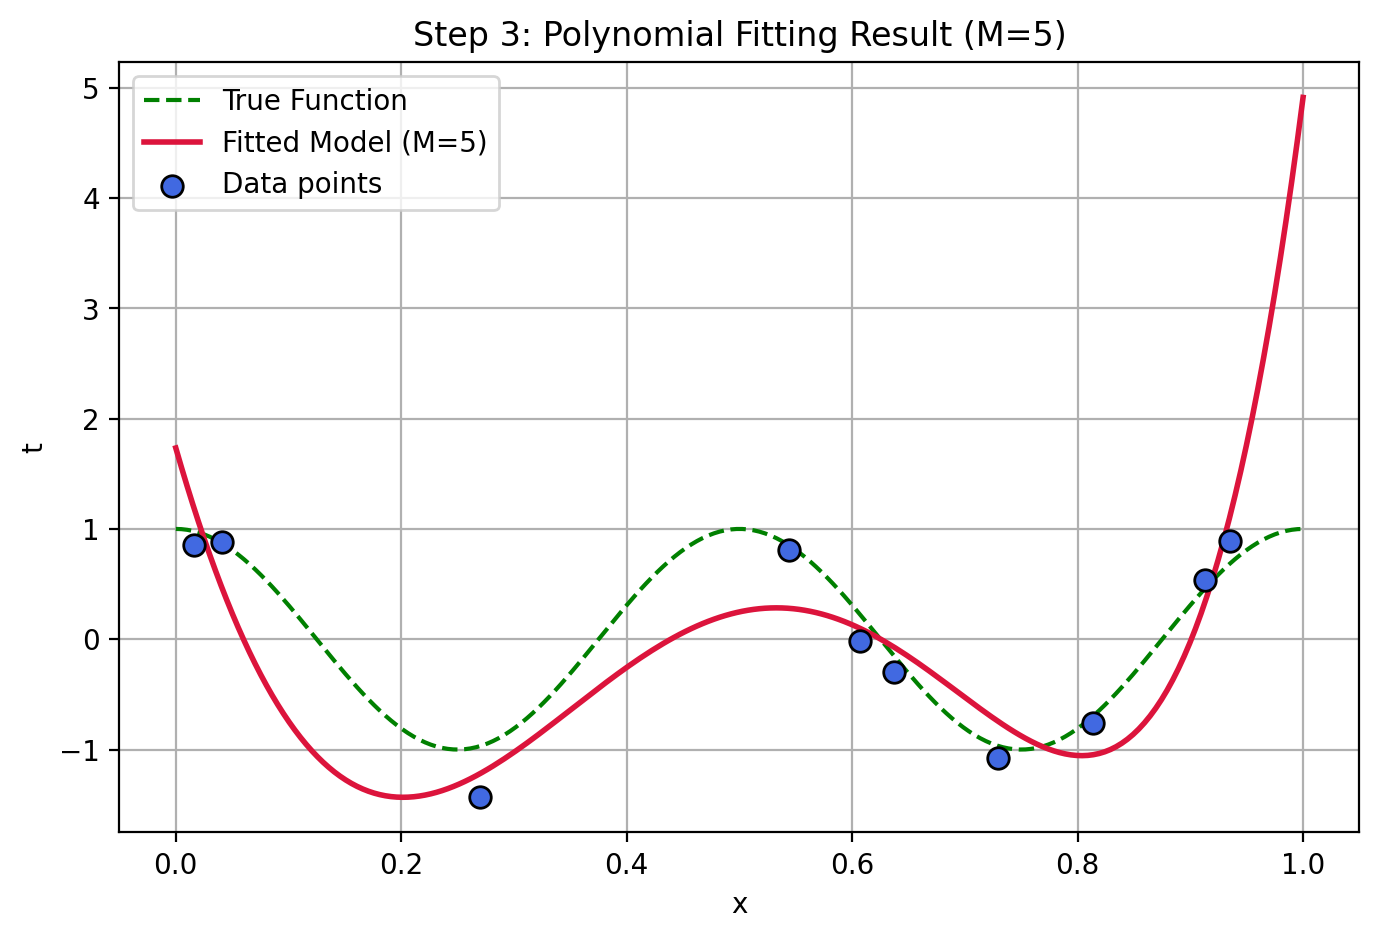

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 描画の設定 ---
# グラフの画質を良くし、目盛り線を表示するように設定する
plt.rcParams['figure.dpi'] = 200
plt.rcParams['axes.grid'] = True

# --- 関数の定義 ---
# 「正解」となる関数の形（コサインカーブ）を定義する
def true_func(x):
  return np.cos(4*np.pi*x) #計算した結果を外に出すcos(4πx)

# ランダムなノイズを含んだデータを生成する関数
def generate_custom_data(n_samples: int, noise_std: float = 0.2, seed: int =42):
    rng = np.random.default_rng(seed)

    # 0から1の範囲でランダムな点xを作り、小さい順に並べる↓
    x = np.sort(rng.uniform(0,1,n_samples))

    # ランダムなノイズ（誤差）を生成↓
    noise = rng.normal(0, noise_std, n_samples)

    # 正解の関数にノイズを足して、実際の「観測データ」を作る↓
    t = true_func(x) + noise

    return x, t #xとtを向上から出荷するイメージ

#実際に10個のデータを作成
x_train, t_train = generate_custom_data(n_samples=10, noise_std=0.2, seed=0)

# グラフを滑らかに描くために、細かく刻んだxを用意して正解の線を計算する
x_dense = np.linspace(0, 1, 200)
x_dense = np.linspace(0, 1, 200)
y_true = true_func(x_dense)
#↑200個のつぶつぶすべてに対して、ノイズの入っていない「きれいなコサインの高さ」を計算して y_true に保存

# --- データの可視化 ---
plt.figure(figsize=(8, 5))
plt.plot(x_dense, y_true, color='green', label='True Function (cos)') #labelはグラフの端に表示する「この線の説明（凡例）」の名前
plt.scatter(x_train, t_train, color='royalblue', s=60, edgecolor='black', label='Generated Data (N=10)', zorder=3)
plt.xlabel('x')
plt.ylabel('t')
plt.title('Step 1: Generated Data with Gauss Noise')
plt.legend()
plt.show()


# --- 学習のための準備 ---
# データから多項式の「設計行列（計算用の表）」を作る関数　(M=5の場合)
def make_design_matrix(x: np.ndarray, M: int = 5) -> np.ndarray:
    # 各データxに対して、[x^0, x^1, x^2, ..., x^M] の数値の組み合わせ（行列）を作る
    return x[:, np.newaxis] ** np.arange(M + 1)

# 試しに10個のデータから設計行列を作ってみる
Phi = make_design_matrix(x_train, M=5)

print("元のデータxの形状:", x_train.shape)
print("設計行列Phiの形状 (10データ × 4列):", Phi.shape)
print("\n最初の3データ分の設計行列の中身（1, x, x^2, x^3, x^4, x^5）:")
print(Phi[:3])


# 最適な重み w を計算する関数
# 観測データに最も当てはまるような「重み（係数）」を数学的に計算する
def fit_custom_polynomial(Phi: np.ndarray, t: np.ndarray) -> np.ndarray:
    # 正規方程式 (Phi^T * Phi) * w = Phi^T * t を解く
    # np.linalg.solve は逆行列を直接計算するより数値的に安全で高速です
    w = np.linalg.solve(Phi.T @ Phi, Phi.T @ t)
    return w

# --- 予測と表示 ---
# 求まった w を使って予測値を計算する関数
def predict_custom(x: np.ndarray, w: np.ndarray) -> np.ndarray:
    M = len(w) - 1
    Phi_dense = make_design_matrix(x, M)
    return Phi_dense @ w

# --- 実行 ---
# 10個のデータから w を学習 (M=5)
w_optimized = fit_custom_polynomial(Phi, t_train)
print("求まった最適な重み w (w0, w1, w2, w3, w4, w5):")
print(np.round(w_optimized, 5))

# 学習した w を使って、滑らかな予測曲線の値を作る
y_pred = predict_custom(x_dense, w_optimized)

# 結果の可視化
plt.figure(figsize=(8, 5))
plt.plot(x_dense, y_true, color='green', linestyle='--', label='True Function')
plt.plot(x_dense, y_pred, color='crimson', linewidth=2, label='Fitted Model (M=5)')
plt.scatter(x_train, t_train, color='royalblue', s=60, edgecolor='black', label='Data points', zorder=3)
plt.xlabel('x')
plt.ylabel('t')
plt.title('Step 3: Polynomial Fitting Result (M=5)')
plt.legend()
plt.show()

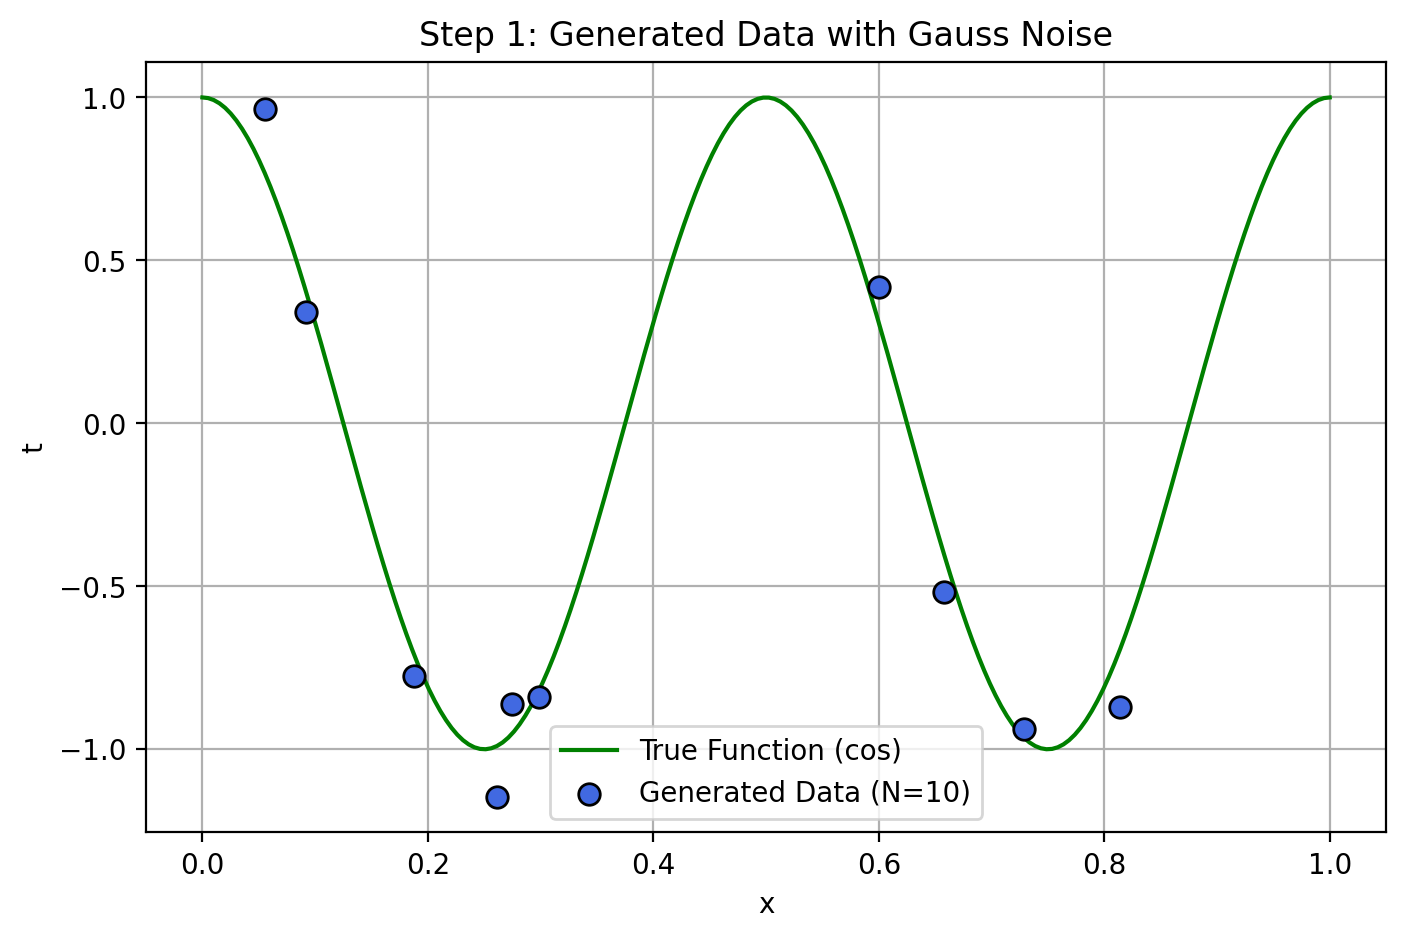

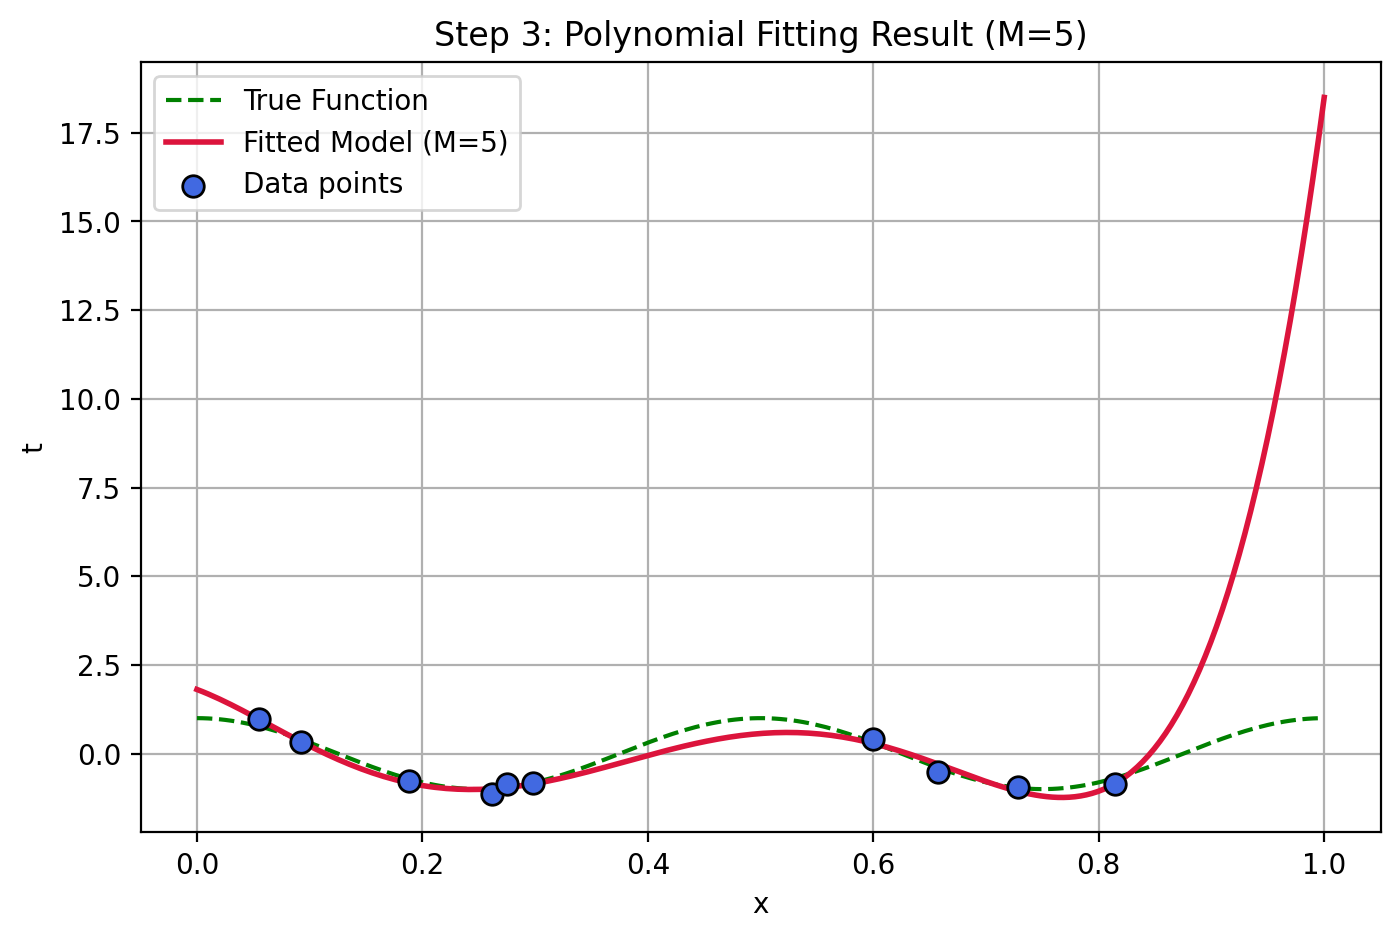

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- Plotting Configuration ---
# Set the plot quality and enable grid lines
plt.rcParams['figure.dpi'] = 200
plt.rcParams['axes.grid'] = True

# --- Function Definitions ---
# Define the "ground truth" function (cosine curve)
def true_func(x):
    return np.cos(4 * np.pi * x)

# Generate synthetic data with random noise
def generate_custom_data(n_samples: int, noise_std: float = 0.2, seed: int = 42):
    rng = np.random.default_rng(seed)
    # Generate random x values in the range [0, 1] and sort them
    x = np.sort(rng.uniform(0, 1, n_samples))
    # Generate random noise (Gaussian)
    noise = rng.normal(0, noise_std, n_samples)
    # Add noise to the ground truth to create "observed data"
    t = true_func(x) + noise
    return x, t

# Create 10 sample data points
x_train, t_train = generate_custom_data(n_samples=10, noise_std=0.2, seed=2)

# Create a smooth range for plotting the true function
x_dense = np.linspace(0, 1, 200)
y_true = true_func(x_dense)

# --- Data Visualization ---
plt.figure(figsize=(8, 5))
plt.plot(x_dense, y_true, color='green', label='True Function (cos)')
plt.scatter(x_train, t_train, color='royalblue', s=60, edgecolor='black', label='Generated Data (N=10)', zorder=3)
plt.xlabel('x')
plt.ylabel('t')
plt.title('Step 1: Generated Data with Gauss Noise')
plt.legend()
plt.show()

# --- Preparation for Training ---
# Create a design matrix for polynomial fitting
def make_design_matrix(x: np.ndarray, M: int = 5) -> np.ndarray:
    # Construct the matrix [x^0, x^1, x^2, ..., x^M]
    return x[:, np.newaxis] ** np.arange(M + 1)

# Create the design matrix from training data
Phi = make_design_matrix(x_train, M=5)

# --- Training (Calculating Optimal Weights) ---
# Calculate the optimal weights using the Normal Equation
def fit_custom_polynomial(Phi: np.ndarray, t: np.ndarray) -> np.ndarray:
    # Solve (Phi.T @ Phi) * w = Phi.T @ t
    w = np.linalg.solve(Phi.T @ Phi, Phi.T @ t)
    return w

# --- Prediction and Visualization ---
# Predict values using the learned weights
def predict_custom(x: np.ndarray, w: np.ndarray) -> np.ndarray:
    M = len(w) - 1
    Phi_dense = make_design_matrix(x, M)
    return Phi_dense @ w

# Optimize weights and compute predicted curve
w_optimized = fit_custom_polynomial(Phi, t_train)
y_pred = predict_custom(x_dense, w_optimized)

# --- Final Visualization ---
plt.figure(figsize=(8, 5))
plt.plot(x_dense, y_true, color='green', linestyle='--', label='True Function')
plt.plot(x_dense, y_pred, color='crimson', linewidth=2, label='Fitted Model (M=5)')
plt.scatter(x_train, t_train, color='royalblue', s=60, edgecolor='black', label='Data points', zorder=3)
plt.xlabel('x')
plt.ylabel('t')
plt.title('Step 3: Polynomial Fitting Result (M=5)')
plt.legend()
plt.show()